# 03. Wyjaśnialność modeli XAI

W tej części projektu przeprowadzono analizę wyjaśnialności modeli. Celem jest sprawdzenie, które cechy najbardziej wpływają na predykcje oraz czy decyzje modeli są zgodne z intuicją dotyczącą problemu przewidywania cukrzycy.

Analiza obejmuje zarówno wyjaśnienia globalne, dotyczące ogólnego działania modelu, jak i wyjaśnienia lokalne, dotyczące pojedynczych predykcji.

## Regresja logistyczna

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [4]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

for col in zero_columns:
    X_train_clean[col] = X_train_clean[col].replace(0, np.nan)
    X_test_clean[col] = X_test_clean[col].replace(0, np.nan)
    

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

pipeline_logistic.fit(X_train_clean, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


## Współczynniki modelu Logistic Regression

Regresja logistyczna jest modelem z natury wyjaśnialnym. Po wytrenowaniu modelu można przeanalizować jego współczynniki, aby sprawdzić, które cechy zwiększają lub zmniejszają prawdopodobieństwo klasy 1, czyli występowania cukrzycy.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

model = pipeline_logistic.named_steps["model"]

coefficients = pd.Series(
    model.coef_[0],
    index=X_train_clean.columns
)

coefficients.sort_values()

Insulin                    -0.066119
BloodPressure              -0.044111
SkinThickness               0.028321
Age                         0.147794
DiabetesPedigreeFunction    0.233337
Pregnancies                 0.377446
BMI                         0.688652
Glucose                     1.182567
dtype: float64

Model uznał, że największe znaczenie mają

Glucose — poziom glukozy
BMI — wskaźnik masy ciał
Pregnancies — liczba ciąż

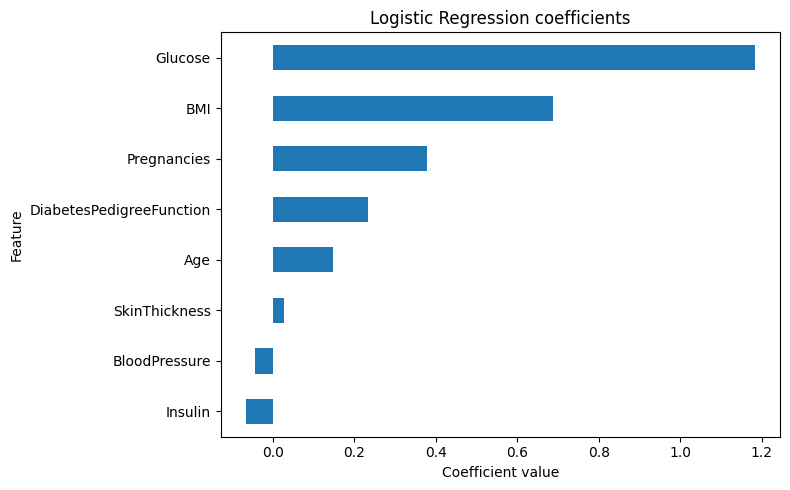

In [8]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

coefficients.sort_values().plot.barh(figsize=(8, 5))

plt.title("Logistic Regression coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("../outputs/figures/logistic_coefficients.png", dpi=300)

plt.show()

## Permutation Importance - regresja logistyczna

In [9]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_logistic = permutation_importance(
    pipeline_logistic,
    X_test_clean,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_logistic_df = pd.DataFrame({
    "Feature": X_test_clean.columns,
    "Importance mean": result_logistic.importances_mean,
    "Importance std": result_logistic.importances_std
}).sort_values("Importance mean", ascending=False)

importance_logistic_df

,Feature,Importance mean,Importance std
1,Glucose,0.159907,0.032571
5,BMI,0.030907,0.018049
0,Pregnancies,0.026111,0.010066
6,DiabetesPedigreeFunction,0.008611,0.003394
7,Age,0.002315,0.001927
4,Insulin,0.001796,0.002329
2,BloodPressure,0.001278,0.000660
3,SkinThickness,0.000056,0.000881


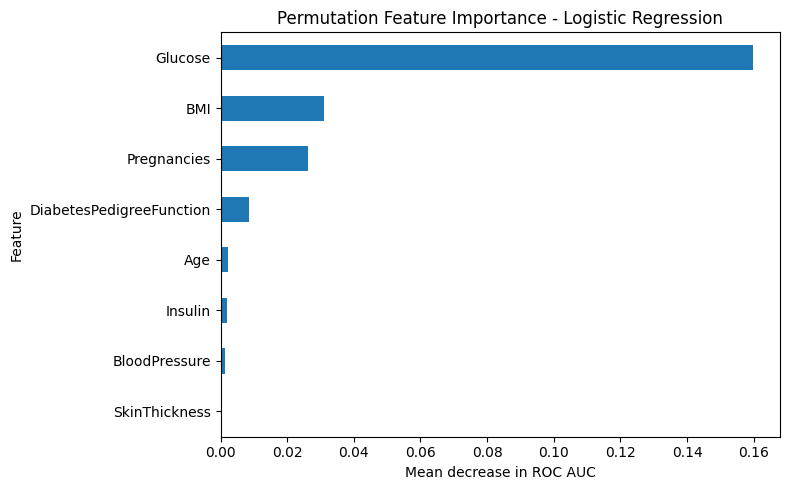

In [10]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

importance_logistic_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Logistic Regression")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_logistic.png", dpi=300)

plt.show()

Wyniki Permutation Importance pokazują, że najważniejszą cechą dla modelu Logistic Regression jest `Glucose`. Jej losowe przemieszanie powoduje największy spadek wartości ROC AUC, co oznacza, że model silnie wykorzystuje tę zmienną podczas predykcji.

Kolejne ważne cechy to `BMI` oraz `Pregnancies`, jednak ich wpływ jest wyraźnie mniejszy niż wpływ poziomu glukozy. Cechy takie jak `SkinThickness`, `BloodPressure` oraz `Insulin` mają bardzo niskie wartości ważności, co oznacza, że ich zaburzenie prawie nie pogarsza jakości modelu.

Wyniki są zgodne z wcześniejszą analizą współczynników regresji logistycznej, gdzie `Glucose` również miała największy dodatni wpływ na przewidywanie klasy 1.

## Random Forest

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_rf.fit(X_train_clean, y_train)

print("Random Forest trained.")

Random Forest trained.


## 3. Permutation Feature Importance dla Random Forest

Random Forest jest modelem złożonym, dlatego trudniej bezpośrednio odczytać sposób podejmowania decyzji. Z tego powodu zastosowano Permutation Importance, aby sprawdzić, które cechy najbardziej wpływają na jakość predykcji tego modelu.

In [12]:
from sklearn.inspection import permutation_importance
import pandas as pd

result_rf = permutation_importance(
    pipeline_rf,
    X_test_clean,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_rf_df = pd.DataFrame({
    "Feature": X_test_clean.columns,
    "Importance mean": result_rf.importances_mean,
    "Importance std": result_rf.importances_std
}).sort_values("Importance mean", ascending=False)

importance_rf_df

,Feature,Importance mean,Importance std
1,Glucose,0.085898,0.023383
5,BMI,0.046361,0.013770
7,Age,0.021222,0.008970
6,DiabetesPedigreeFunction,0.010120,0.006778
0,Pregnancies,0.008991,0.011497
4,Insulin,0.005713,0.006941
2,BloodPressure,0.001269,0.006439
3,SkinThickness,0.001009,0.006208


Wyniki Permutation Importance dla modelu Random Forest pokazują, że najważniejszą cechą pozostaje `Glucose`. Jej przemieszanie powoduje największy spadek wartości ROC AUC, co oznacza, że model silnie opiera się na poziomie glukozy podczas przewidywania cukrzycy.

Drugą najważniejszą cechą jest `BMI`, a następnie `Age`, `DiabetesPedigreeFunction` oraz `Pregnancies`. W porównaniu z regresją logistyczną Random Forest przypisuje większe znaczenie wiekowi. Może to wynikać z tego, że model drzewiasty potrafi uchwycić bardziej złożone zależności między cechami.

Cechy takie jak `BloodPressure` i `SkinThickness` mają bardzo niską ważność, co oznacza, że ich przemieszanie prawie nie pogarsza jakości predykcji modelu.

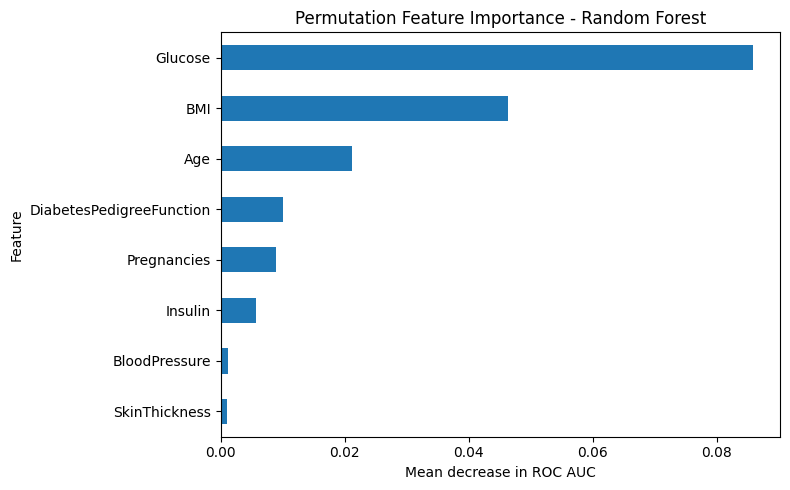

In [13]:
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)

importance_rf_df.sort_values("Importance mean").plot.barh(
    x="Feature",
    y="Importance mean",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/permutation_importance_random_forest.png", dpi=300)

plt.show()

## SHAP dla modelu Random Forest

In [14]:
!pip install shap


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
rf_model = pipeline_rf.named_steps["model"]
imputer = pipeline_rf.named_steps["imputer"]

In [19]:
X_train_rf = pd.DataFrame(
    imputer.transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)

X_test_rf = pd.DataFrame(
    imputer.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

## SHAP summary plot

In [20]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_rf)

In [21]:
type(shap_values_rf), np.array(shap_values_rf).shape

(numpy.ndarray, (154, 8, 2))

154 = liczba obserwacji w X_test
8 = liczba cech
2 = dwie klasy

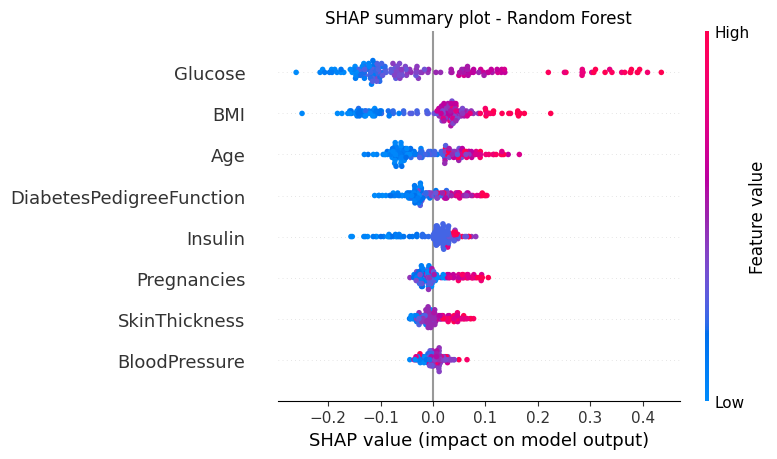

In [ ]:
shap.summary_plot(
    shap_values_rf[:, :, 1], # with diabeties
    X_test_rf,
    show=False
)

plt.title("SHAP summary plot - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

Wykres SHAP summary plot pokazuje globalny wpływ cech na predykcje modelu Random Forest. Najważniejszą cechą jest `Glucose`, co oznacza, że poziom glukozy miał największy wpływ na decyzje modelu. Wysokie wartości glukozy przesuwają predykcję w stronę klasy 1, czyli cukrzycy, natomiast niższe wartości zmniejszają przewidywane ryzyko.

Istotne znaczenie mają również `BMI`, `Age` oraz `DiabetesPedigreeFunction`. Wyniki są zgodne z wcześniejszą analizą Permutation Importance, ponieważ również tam `Glucose` i `BMI` należały do najważniejszych cech.

Cechy znajdujące się niżej, takie jak `SkinThickness` i `BloodPressure`, mają mniejszy wpływ na predykcje modelu.

## SHAP bar plot

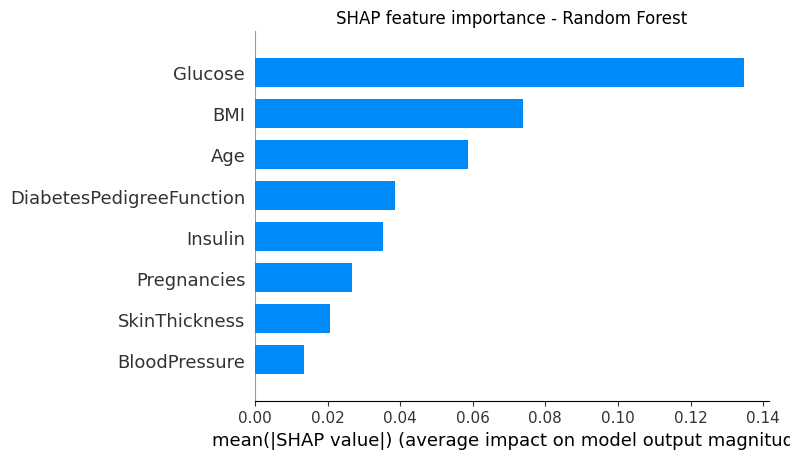

In [23]:
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test_rf,
    plot_type="bar",
    show=False
)

plt.title("SHAP feature importance - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

Wykres słupkowy SHAP pokazuje ranking cech według ich średniego wpływu na predykcje modelu Random Forest. Najważniejszą cechą jest `Glucose`, co potwierdza wcześniejsze wyniki uzyskane za pomocą Permutation Importance. Wysoko znajdują się również `BMI`, `Age` oraz `DiabetesPedigreeFunction`, co oznacza, że model często wykorzystuje te zmienne przy przewidywaniu klasy 1, czyli cukrzycy.

Wyniki SHAP są spójne z wcześniejszymi analizami — zarówno regresja logistyczna, jak i Random Forest wskazują, że poziom glukozy jest najważniejszą zmienną w tym problemie.

## SHAP waterfall

In [24]:
i = 0

sample_df = X_test_rf.iloc[[i]]

prediction = rf_model.predict(sample_df)[0]
prediction_proba = rf_model.predict_proba(sample_df)[0, 1] # pierwsza osoba, prawdopodobieństwo klasy 1

print("Predicted class:", prediction)
print("Predicted probability of class 1:", prediction_proba)

Predicted class: 1
Predicted probability of class 1: 0.685


c:\Users\AS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\AS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


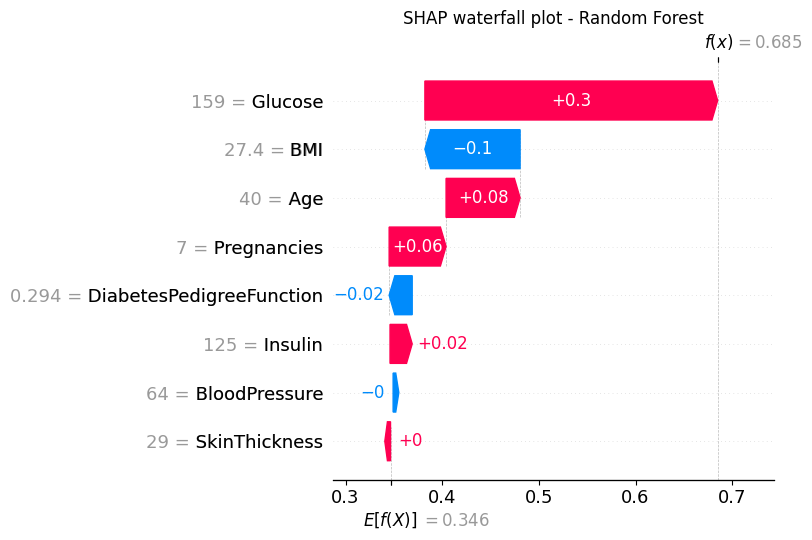

In [25]:
sample = X_test_rf.iloc[i]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_rf[i, :, 1],
        base_values=explainer_rf.expected_value[1],
        data=sample,
        feature_names=X_test_rf.columns
    ),
    show=False
)

plt.title("SHAP waterfall plot - Random Forest")
plt.tight_layout()

plt.savefig("../outputs/figures/shap_waterfall_random_forest.png", dpi=300, bbox_inches="tight")

plt.show()

Wykres waterfall przedstawia lokalne wyjaśnienie jednej predykcji modelu Random Forest. Dla analizowanej obserwacji model przewidział klasę 1, czyli cukrzycę, z prawdopodobieństwem około 68,5%.

Najsilniej w stronę klasy 1 przesunęła predykcję cecha `Glucose` o wartości 159. Dodatni wpływ miały również `Age`, `Pregnancies` oraz `Insulin`. Z kolei `BMI` oraz `DiabetesPedigreeFunction` zmniejszały przewidywane prawdopodobieństwo cukrzycy.

Interpretacja lokalna jest zgodna z wcześniejszymi wynikami globalnymi, ponieważ również tutaj poziom glukozy okazał się najważniejszą cechą wpływającą na decyzję modelu.